# Extraction-Recall Booster for the Closure-Certificate Net-Utility Fork

**Artifact `art_fXvxt4JO9hWy` (iter-9).** This demo reproduces the *headline analysis* of an
experiment that asks: **can a better atomic-fact extractor flip the iter-8 "extraction-limited"
verdict** of a no-derivation closure certificate?

The full pipeline runs >=4 prompt-only extraction strategies (few-shot-enum, sentence-wise+coref,
self-consistency-union, multi-model-union, each with a precision guard) over two genuinely-natural
Re-DocRED absent-relation domains (located-in administrative containment + kinship), re-derives the
closure certificate per strategy, and scores a mixed-pool *confident-wrong reduction* against six
competing confidence signals. Those LLM extractions cost a one-time ~\$1.21 of real OpenRouter
completions and are **pre-computed** — this notebook loads the cached per-strategy results and
re-runs the *pure-numeric analysis* that produces the paper's central claim:

> Raising prompt-only recall **measurably lifts** the certificate's coverage (located-in 0.148 -> 0.227
> recall, present coverage ~3x), **but the recall is precision-bought**: the worst-case confident-wrong
> *reduction* moves **away** from a flip as recall rises (slope -0.30 located-in / -0.67 kinship).
> No prompt-only strategy flips the fork ⇒ **EXTRACTION-LIMITED-BOUNDARY-CONFIRMED** on both domains.

What this notebook does (no LLM / API calls needed):
1. Reproduces `build_frontier(...)` **verbatim from the original `method.py`** on the cached
   per-strategy rows -> the recall-vs-reduction slope (the headline).
2. Computes the **dose-response** correlations (recall -> present-coverage, recall -> false sibling edges).
3. Re-derives **FACT A** and the certificate's structural-abstention advantage directly from a
   sample of decisive *sibling-absent* example rows.
4. Shows the **stronger cross-model verifier** robustness result.
5. Plots the frontier, the dose-response, and the verifier comparison.

## Setup

### Install dependencies
The analysis only needs `numpy`, `pandas` and `matplotlib` (all pre-installed on Colab). On Colab
we use Colab's versions; locally we pin Colab's exact versions so the environment matches.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, matplotlib are pre-installed on Colab -> install locally only, at Colab versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


### Imports
The original `method.py` imports the whole iter-8/iter-9 harness (`core`, `kinship`, `booster`,
`llm`, ...) to *generate* the cached completions. This demo reuses only the parts of `method.py`
that analyse the cached results, so we import just the scientific-Python stack used by that
analysis.

In [2]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load the pre-computed results
`mini_demo_data.json` is a curated subset of the experiment's `method_out.json`: the per-strategy
metadata rows for both domains, the frontier blocks, FACT A, the stronger-verifier block, and 100
diverse `locatedin_absent_sibling` example rows. Loads from GitHub (Colab) with a local fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-9/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
META = data["metadata"]
LOC = META["located_in"]          # located-in administrative-containment domain
KIN = META["kinship"]             # kinship domain
SIB_EXAMPLES = data["examples"]   # decisive sibling-absent located-in example rows

print("reader model      :", META["reader_model"])
print("located-in rows   :", [r["strategy"] for r in LOC["per_strategy_rows"]])
print("kinship rows      :", [r["strategy"] for r in KIN["per_strategy_rows"]])
print("sibling examples  :", len(SIB_EXAMPLES))
print("overall verdict   :", META["overall_verdict"])

reader model      : google/gemini-3.1-flash-lite
located-in rows   : ['default', 'best_effort', 'fewshot_enum', 'sentencewise', 'sc_union', 'multimodel_union', 'sc_union_highprec', 'multimodel_union_highprec']
kinship rows      : ['default', 'fewshot_enum', 'sentencewise', 'sc_union', 'multimodel_union', 'sc_union_highprec', 'multimodel_union_highprec']
sibling examples  : 100
overall verdict   : EXTRACTION-LIMITED-BOUNDARY-CONFIRMED


## Config

All tunable knobs live here. The defaults are the **minimum** that still produce meaningful output;
raise them for a fuller demo (the analysis is fast — everything is pre-computed).

- `N_DEMO_EXAMPLES` — how many of the loaded sibling-absent rows to score in the per-example
  reproduction (Section 3). Min 5; up to `len(SIB_EXAMPLES)` (=100).
- `BOOTSTRAP_B` — bootstrap resamples for the FACT-A / fraction-caught confidence intervals.
  Min 100; the paper uses 10000.

In [5]:
# --- tunable demo parameters ---
# Minimum-that-runs values (used during bring-up): N_DEMO_EXAMPLES=5, BOOTSTRAP_B=100
# Scaled-up values below use the full loaded sample (the analysis is fast - all pre-computed).
N_DEMO_EXAMPLES = len(SIB_EXAMPLES)   # =100 (full loaded sample) ; min that runs = 5
BOOTSTRAP_B     = 2000                # paper value = META['bootstrap_B'] (=10000) ; min = 100

SEED = META["seed"]           # 20260618 (pre-registered)
print(f"N_DEMO_EXAMPLES={N_DEMO_EXAMPLES}  BOOTSTRAP_B={BOOTSTRAP_B}  SEED={SEED}")

N_DEMO_EXAMPLES=100  BOOTSTRAP_B=2000  SEED=20260618


## 1. The recall-vs-reduction frontier (`build_frontier`, verbatim from `method.py`)

This is the load-bearing function copied **unchanged** from the original `method.py`. It sorts the
per-strategy rows by atomic recall and fits a line of the worst-case mixed-pool confident-wrong
*reduction CI-lower* against recall. A **negative** slope means: more prompt-only recall pushes the
certificate's worst case *further* from beating all six competitors — i.e. the boundary is
fundamental, not a tuning artifact.

In [6]:
def _r(x, nd=4):
    # rounding helper, verbatim from method.py
    return None if x is None else (round(float(x), nd) if isinstance(x, (int, float)) else x)


def build_frontier(rows):
    rows_sorted = sorted(rows, key=lambda x: (x["atomic_recall_canon"]
                                              if isinstance(x["atomic_recall_canon"], (int, float)) else -1))
    frontier = [{"strategy": x["strategy"], "recall": x["atomic_recall_canon"],
                 "precision": x["atomic_precision_canon"], "present_coverage": x["present_coverage"],
                 "min_over6_reduction": x["min_over6_reduction"], "min_over6_ci_lo": x["min_over6_ci_lo"],
                 "certificate_fraction_caught_sibling": x["certificate_fraction_caught_sibling"],
                 "absent_sibling_cw_certificate": x["absent_sibling_confident_wrong_certificate"],
                 "flip_flag": x["flip_flag"], "sub_verdict": x["sub_verdict"]} for x in rows_sorted]
    rs = np.array([x["recall"] for x in frontier if isinstance(x["recall"], (int, float))], float)
    cilo = np.array([x["min_over6_ci_lo"] for x in frontier
                     if isinstance(x["min_over6_ci_lo"], (int, float))], float)
    pc = np.array([x["present_coverage"] for x in frontier
                   if isinstance(x["present_coverage"], (int, float))], float)
    needed = slope = pc_slope = None
    if len(rs) >= 2 and float(np.ptp(rs)) > 1e-6:
        a, b = np.polyfit(rs, cilo, 1)
        slope = float(a)
        if a > 1e-9:
            needed = float((0.0 - b) / a)
        if len(pc) == len(rs):
            pc_slope = float(np.polyfit(rs, pc, 1)[0])
    valid = [x for x in rows if isinstance(x["min_over6_reduction"], (int, float))]
    red_opt = max(valid, key=lambda x: x["min_over6_reduction"])["strategy"] if valid else None
    if slope is None:
        finding = "insufficient recall spread to estimate a slope."
    elif slope <= 1e-9:
        finding = ("NEGATIVE/zero slope: raising prompt-only extraction recall moves the WORST-case mixed-pool "
                   "reduction CI FURTHER from 0, not toward it. The recall lift is PRECISION-BOUGHT (injected false "
                   "edges make the certificate fabricate sibling paths and mis-derive present pairs), so NO promptable "
                   "recall flips the fork. The reduction-optimal operating point is the LOWEST-recall / HIGHEST-precision "
                   f"strategy ('{red_opt}'), confirming PRECISION -- not recall -- is the binding dual constraint.")
    elif needed is not None:
        finding = (f"POSITIVE slope: extrapolated atomic recall {needed:.3f} would make the worst-case mixed reduction "
                   f"CI cross 0 (the certificate would beat all 6 competitors). Current best realized recall "
                   f"{float(rs.max()):.3f}.")
    else:
        finding = "POSITIVE slope; intercept already >=0 within the observed recall range."
    extrap = {"min_over6_ci_lo_vs_recall_slope": _r(slope) if slope is not None else None,
              "extrapolated_recall_for_min_ci_lo_to_cross_0": _r(needed) if needed is not None else None,
              "present_coverage_vs_recall_slope": _r(pc_slope) if pc_slope is not None else None,
              "reduction_optimal_strategy": red_opt,
              "interpretation_finding": finding}
    return frontier, extrap

In [7]:
loc_frontier, loc_extrap = build_frontier(LOC["per_strategy_rows"])
kin_frontier, kin_extrap = build_frontier(KIN["per_strategy_rows"])

cols = ["strategy", "recall", "precision", "present_coverage",
        "min_over6_reduction", "min_over6_ci_lo",
        "certificate_fraction_caught_sibling", "absent_sibling_cw_certificate", "flip_flag"]
print("=== LOCATED-IN frontier (sorted by recall) ===")
display(pd.DataFrame(loc_frontier)[cols].round(4))
print("\nslope(min_over6_ci_lo ~ recall) =", loc_extrap["min_over6_ci_lo_vs_recall_slope"],
      " | present_coverage slope =", loc_extrap["present_coverage_vs_recall_slope"])
print("reduction-optimal strategy      =", loc_extrap["reduction_optimal_strategy"])
print("any strategy flips the fork?    =", any(r["flip_flag"] for r in loc_frontier))

=== LOCATED-IN frontier (sorted by recall) ===


,strategy,recall,precision,present_coverage,min_over6_reduction,min_over6_ci_lo,certificate_fraction_caught_sibling,absent_sibling_cw_certificate,flip_flag
0,multimodel_union_highprec,0.0541,0.6452,0.0117,-0.0166,-0.0253,0.8815,0.0356,False
1,sc_union_highprec,0.0841,0.6154,0.0330,-0.0218,-0.0319,0.8519,0.0467,False
2,default,0.1478,0.6649,0.0505,-0.0342,-0.0502,0.7852,0.0733,False
3,best_effort,0.1859,0.6885,0.1126,-0.0446,-0.0604,0.7111,0.0956,False
4,sentencewise,0.1962,0.6225,0.1359,-0.0653,-0.0861,0.5852,0.1400,False
5,multimodel_union,0.2031,0.5808,0.1359,-0.0518,-0.0704,0.6963,0.1111,False
6,fewshot_enum,0.2130,0.6583,0.1631,-0.0466,-0.0639,0.6963,0.1000,False
7,sc_union,0.2268,0.6475,0.1650,-0.0549,-0.0740,0.6593,0.1178,False



slope(min_over6_ci_lo ~ recall) = -0.3038  | present_coverage slope = 0.9202
reduction-optimal strategy      = multimodel_union_highprec
any strategy flips the fork?    = False


In [8]:
print("=== KINSHIP frontier (sorted by recall) ===")
display(pd.DataFrame(kin_frontier)[cols].round(4))
print("\nslope(min_over6_ci_lo ~ recall) =", kin_extrap["min_over6_ci_lo_vs_recall_slope"])
print("any strategy flips the fork?    =", any(r["flip_flag"] for r in kin_frontier))
print("\nINTERPRETATION (located-in):\n ", loc_extrap["interpretation_finding"])

=== KINSHIP frontier (sorted by recall) ===


,strategy,recall,precision,present_coverage,min_over6_reduction,min_over6_ci_lo,certificate_fraction_caught_sibling,absent_sibling_cw_certificate,flip_flag
0,multimodel_union_highprec,0.1059,0.5078,0.0430,-0.0132,-0.0273,0.9726,0.008,False
1,sc_union_highprec,0.2130,0.5710,0.1004,-0.0340,-0.0648,0.8630,0.044,False
2,multimodel_union,0.3351,0.5720,0.3513,-0.1248,-0.1832,0.7397,0.100,False
3,sentencewise,0.3643,0.5965,0.5735,-0.1720,-0.2327,0.7123,0.088,False
4,default,0.3762,0.6203,0.4731,-0.0907,-0.1395,0.8219,0.068,False
5,sc_union,0.3838,0.5754,0.5914,-0.1664,-0.2300,0.7123,0.096,False
6,fewshot_enum,0.3957,0.6299,0.5591,-0.1380,-0.2021,0.7260,0.084,False



slope(min_over6_ci_lo ~ recall) = -0.6724
any strategy flips the fork?    = False

INTERPRETATION (located-in):
  NEGATIVE/zero slope: raising prompt-only extraction recall moves the WORST-case mixed-pool reduction CI FURTHER from 0, not toward it. The recall lift is PRECISION-BOUGHT (injected false edges make the certificate fabricate sibling paths and mis-derive present pairs), so NO promptable recall flips the fork. The reduction-optimal operating point is the LOWEST-recall / HIGHEST-precision strategy ('multimodel_union_highprec'), confirming PRECISION -- not recall -- is the binding dual constraint.


## 2. Dose-response: recall buys coverage *and* false sibling edges

If recall were a free lunch we would expect it to lift present-coverage while leaving the
false-edge rate flat. Instead recall correlates **almost perfectly with both** — the same extra
edges that raise coverage also inject false sibling links that make the certificate fabricate
containment paths. This is the mechanism behind the negative frontier slope above.

In [9]:
rows = LOC["per_strategy_rows"]
rec  = np.array([r["atomic_recall_canon"] for r in rows], float)
pcov = np.array([r["present_coverage"] for r in rows], float)
sibcw = np.array([r["absent_sibling_confident_wrong_certificate"] for r in rows], float)

corr_recall_cov   = float(np.corrcoef(rec, pcov)[0, 1])
corr_recall_sibcw = float(np.corrcoef(rec, sibcw)[0, 1])
print(f"corr(recall, present_coverage)          = {corr_recall_cov:.3f}   (recall really does buy coverage)")
print(f"corr(recall, sibling confident-wrong)   = {corr_recall_sibcw:.3f}   (... and false sibling edges in lock-step)")
print(f"present-coverage lift, lowest->highest recall : "
      f"{pcov.min():.4f} -> {pcov.max():.4f}  ({pcov.max()/max(pcov.min(),1e-9):.1f}x)")

corr(recall, present_coverage)          = 0.963   (recall really does buy coverage)
corr(recall, sibling confident-wrong)   = 0.914   (... and false sibling edges in lock-step)
present-coverage lift, lowest->highest recall : 0.0117 -> 0.1650  (14.1x)


## 3. FACT A + the certificate's structural-abstention advantage (per-example)

Now we leave the aggregate rows and re-derive the result **directly from individual decisive
`sibling-absent` rows** (gold = *no-relation*; the two places are siblings in the same admin tree,
never one inside the other).

- **FACT A** — the raw LLM *confidently asserts* a containment on ~30% of these pairs (mean conf ~0.94).
- A method is **confident-wrong** on an absent pair if it returns any named relation instead of `ABSTAIN`.
- The certificate **abstains structurally** (no derivation -> no relation), so it catches most of
  these hallucinations; the confidence-thresholded competitors and the query-side verifier inherit
  the LLM's confident error.

All numbers are recomputed from the loaded prediction strings — no model is queried.

In [10]:
def is_named(pred):
    # an absent-pair prediction is "confident-wrong" iff it is any named relation (not ABSTAIN)
    return pred not in (None, "ABSTAIN", "no-relation")

ex = SIB_EXAMPLES[:N_DEMO_EXAMPLES]
n = len(ex)

# FACT A: raw-LLM confident containment hallucinations on sibling-absent pairs
halluc = [e for e in ex if e["metadata_raw_named"]]
factA_rate = len(halluc) / n
factA_conf = float(np.mean([e["metadata_conf_verbalized"] for e in halluc])) if halluc else float("nan")

# confident-wrong rate of each method on the absent pool (lower = better)
METHODS = {
    "certificate (best strategy)": "predict_certificate_best",
    "certificate (default S0)":    "predict_certificate_default_S0",
    "raw LLM commit (argmax)":     "predict_commit_argmax",
    "conf-thresh verbalized":      "predict_conf_thresh_verbalized",
    "conf-thresh P(True)":         "predict_conf_thresh_ptrue",
    "conf-thresh sc-margin":       "predict_conf_thresh_sc_margin",
    "query-side verifier":         "predict_queryside_verifier",
    "query-side self-verify":      "predict_queryside_selfverify",
}
cw = {name: float(np.mean([is_named(e[key]) for e in ex])) for name, key in METHODS.items()}

# certificate fraction-caught: among raw hallucinations, fraction the certificate abstains on
frac_caught_cert = (float(np.mean([not is_named(e["predict_certificate_best"]) for e in halluc]))
                    if halluc else float("nan"))

print(f"sample size                                : {n}")
print(f"FACT A  raw-LLM sibling hallucination rate : {factA_rate:.3f}  (mean confidence {factA_conf:.3f})")
print(f"certificate fraction-caught (this sample)  : {frac_caught_cert:.3f}")
print()
print("confident-wrong rate on the sibling-absent pool (lower is better):")
for name in METHODS:
    print(f"   {name:<30s} {cw[name]:.3f}")

sample size                                : 100
FACT A  raw-LLM sibling hallucination rate : 0.370  (mean confidence 0.912)
certificate fraction-caught (this sample)  : 0.703

confident-wrong rate on the sibling-absent pool (lower is better):
   certificate (best strategy)    0.130
   certificate (default S0)       0.090
   raw LLM commit (argmax)        0.370
   conf-thresh verbalized         0.370
   conf-thresh P(True)            0.370
   conf-thresh sc-margin          0.370
   query-side verifier            0.270
   query-side self-verify         0.190


### Bootstrap CIs (doc-level resampling)
A quick percentile bootstrap (controlled by `BOOTSTRAP_B`) over the sampled rows gives 95% CIs for
FACT A and the certificate's fraction-caught.

In [11]:
rng = np.random.default_rng(SEED)

def boot_ci(values, B):
    values = np.asarray(values, float)
    if len(values) == 0:
        return (float("nan"), float("nan"))
    idx = rng.integers(0, len(values), size=(B, len(values)))
    stats = values[idx].mean(axis=1)
    return float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5))

factA_vals = [1.0 if e["metadata_raw_named"] else 0.0 for e in ex]
caught_vals = [1.0 if not is_named(e["predict_certificate_best"]) else 0.0 for e in halluc]

lo1, hi1 = boot_ci(factA_vals, BOOTSTRAP_B)
lo2, hi2 = boot_ci(caught_vals, BOOTSTRAP_B)
print(f"FACT A rate            : {factA_rate:.3f}  95% CI [{lo1:.3f}, {hi1:.3f}]   (B={BOOTSTRAP_B})")
print(f"cert fraction-caught   : {frac_caught_cert:.3f}  95% CI [{lo2:.3f}, {hi2:.3f}]")
print()
print("Full-pool reference values from the experiment metadata (n=450 sibling pairs):")
fa = LOC["FACT_A_per_regime"]["same_component_sibling"]
print(f"   FACT A rate (full)            : {fa['rate']}  (mean conf {fa['hallucination_confidence_distribution']['mean']})")
print(f"   cert fraction-caught (default): {LOC['per_strategy_rows'][0]['certificate_fraction_caught_sibling']}")

FACT A rate            : 0.370  95% CI [0.280, 0.470]   (B=2000)
cert fraction-caught   : 0.703  95% CI [0.568, 0.838]

Full-pool reference values from the experiment metadata (n=450 sibling pairs):
   FACT A rate (full)            : 0.3  (mean conf 0.9422)
   cert fraction-caught (default): 0.7852


## 4. Stronger cross-model verifier (methodology robustness)

Is certificate-necessity just an artifact of using a *weak same-model* verifier? The experiment
re-ran the query-side verifier with a **stronger, larger, different-family** model
(deepseek-v3.2, k=5 self-consistency). It catches **fewer** of the raw LLM's confident sibling
hallucinations than the certificate — a better geographer *over-infers* containment. These numbers
are pre-computed; we just display the block.

In [12]:
sv = LOC["stronger_verifier_block"]
print("strong verifier model :", sv["model"])
print("n sibling / n raw hallucinations :", sv["n_sibling"], "/", sv["n_raw_hallucinations"])
print()
fc = sv["fraction_caught"]
print("fraction of raw-LLM sibling hallucinations CAUGHT (higher = better):")
for k, v in fc.items():
    print(f"   {k:<40s} {v}")
print()
ncw = sv["natural_confident_wrong_on_sibling"]
print("natural confident-wrong on sibling pool (lower = better):")
for k, v in ncw.items():
    print(f"   {k:<40s} {v}")

strong verifier model : deepseek/deepseek-v3.2
n sibling / n raw hallucinations : 250 / 60

fraction of raw-LLM sibling hallucinations CAUGHT (higher = better):
   certificate                              0.6667
   queryside_verifier_weak_same_model       0.2
   queryside_verifier_strong                0.1
   queryside_selfverify_strong              0.5333

natural confident-wrong on sibling pool (lower = better):
   certificate                              0.096
   queryside_verifier_weak_same_model       0.192
   queryside_verifier_strong                0.216
   queryside_selfverify_strong              0.112


## 5. Pre-registered fork verdict

In [13]:
print("FORK definitions:")
for k, v in META["fork"].items():
    print(f"  [{k}]\n    {v}\n")
print("located-in domain verdict :", LOC["domain_verdict"])
print("kinship   domain verdict :", KIN["domain_verdict"])
print("OVERALL verdict          :", META["overall_verdict"])
print()
cl = META["cost_ledger"]
print(f"cost: one-time generation \${cl['one_time_generation_cost_usd_first_run']} ; "
      f"this cached re-run \${cl['total_usd']}")

FORK definitions:
  [DEMONSTRATED-FIX]
    some strategy makes the mixed-pool reduction CI exclude 0 vs ALL 6 competitors AND the certificate's sibling confident-wrong <= the query-side verifier's (flip_flag).

  [EXTRACTION-LIMITED-BOUNDARY-CONFIRMED]
    no strategy flips; the recall-vs-reduction frontier quantifies exactly how much recall is still needed (extrapolated_recall_for_min_ci_lo_to_cross_0).

located-in domain verdict : EXTRACTION-LIMITED-BOUNDARY
kinship   domain verdict : EXTRACTION-LIMITED-BOUNDARY
OVERALL verdict          : EXTRACTION-LIMITED-BOUNDARY-CONFIRMED

cost: one-time generation \$1.207 ; this cached re-run \$0.0


<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_332/3733611885.py:9: SyntaxWarning: invalid escape sequence '\$'
  print(f"cost: one-time generation \${cl['one_time_generation_cost_usd_first_run']} ; "
/tmp/ipykernel_332/3733611885.py:10: SyntaxWarning: invalid escape sequence '\$'
  f"this cached re-run \${cl['total_usd']}")


## 6. Visualization

Four panels: (a) the recall-vs-reduction **frontier** with the fitted slope for both domains;
(b) the **dose-response** of present-coverage and sibling false-edges against recall; (c) the
per-example **confident-wrong** rates; (d) the **stronger-verifier** fraction-caught comparison.

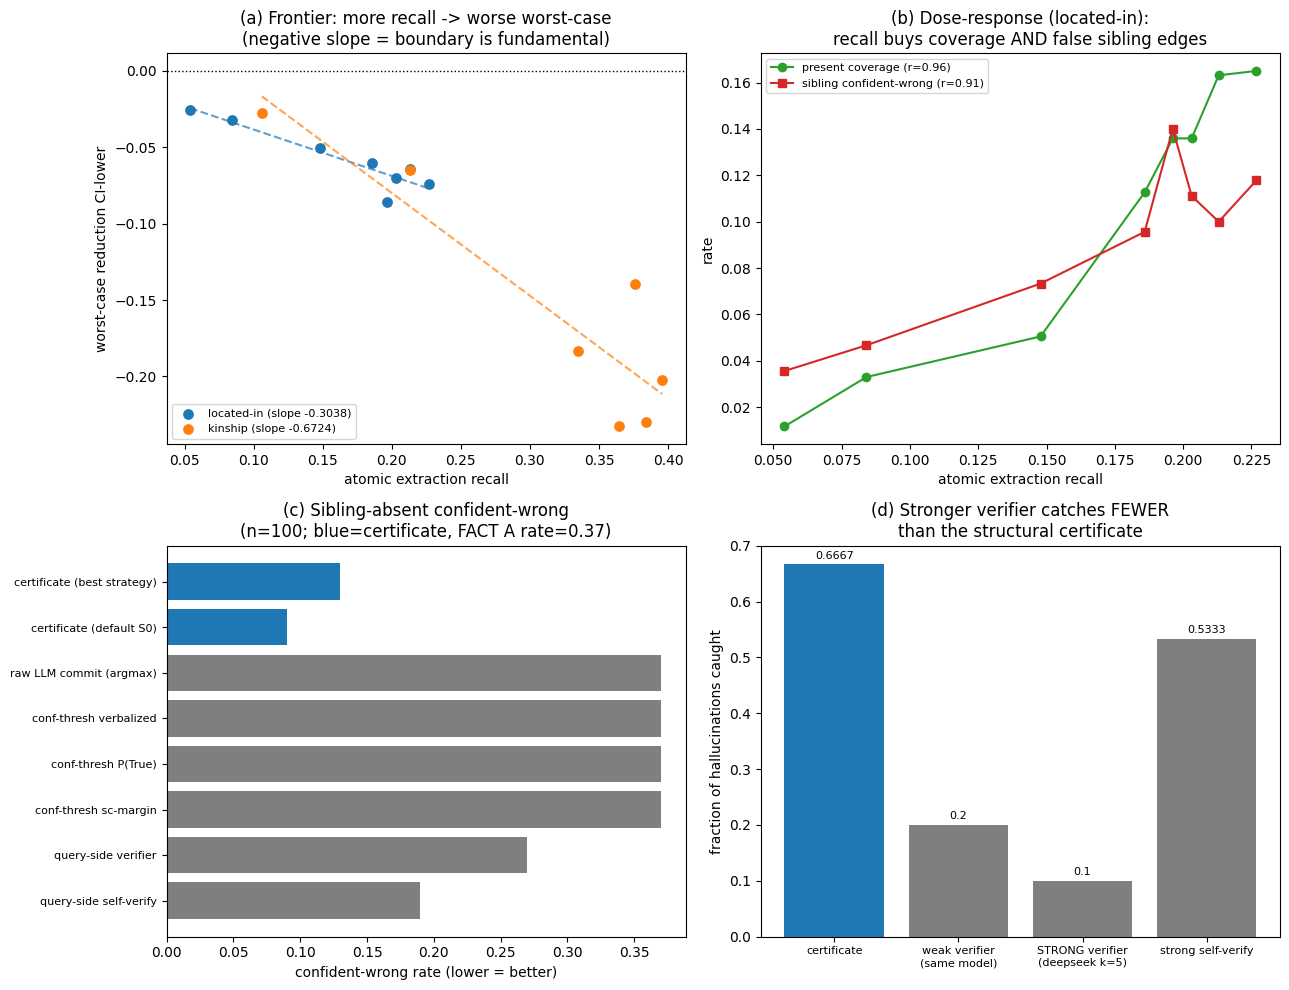

Saved figure -> frontier_demo.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) frontier: recall vs worst-case reduction CI-lower, both domains, with fitted line
ax = axes[0, 0]
for fr, ex_, label, color in [(loc_frontier, loc_extrap, "located-in", "tab:blue"),
                              (kin_frontier, kin_extrap, "kinship", "tab:orange")]:
    r = np.array([x["recall"] for x in fr], float)
    y = np.array([x["min_over6_ci_lo"] for x in fr], float)
    ax.scatter(r, y, color=color, s=45, zorder=3, label=f"{label} (slope {ex_['min_over6_ci_lo_vs_recall_slope']})")
    a, b = np.polyfit(r, y, 1)
    xs = np.linspace(r.min(), r.max(), 50)
    ax.plot(xs, a * xs + b, color=color, ls="--", alpha=.7)
ax.axhline(0, color="k", lw=1, ls=":")
ax.set_xlabel("atomic extraction recall"); ax.set_ylabel("worst-case reduction CI-lower")
ax.set_title("(a) Frontier: more recall -> worse worst-case\n(negative slope = boundary is fundamental)")
ax.legend(fontsize=8)

# (b) dose-response: present coverage and sibling confident-wrong vs recall (located-in)
ax = axes[0, 1]
order = np.argsort(rec)
ax.plot(rec[order], pcov[order], "o-", color="tab:green", label=f"present coverage (r={corr_recall_cov:.2f})")
ax.plot(rec[order], sibcw[order], "s-", color="tab:red", label=f"sibling confident-wrong (r={corr_recall_sibcw:.2f})")
ax.set_xlabel("atomic extraction recall"); ax.set_ylabel("rate")
ax.set_title("(b) Dose-response (located-in):\nrecall buys coverage AND false sibling edges")
ax.legend(fontsize=8)

# (c) per-example confident-wrong rates on the sibling pool
ax = axes[1, 0]
names = list(cw.keys()); vals = [cw[k] for k in names]
colors = ["tab:blue" if "certificate" in nme else "tab:gray" for nme in names]
ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("confident-wrong rate (lower = better)")
ax.set_title(f"(c) Sibling-absent confident-wrong\n(n={n}; blue=certificate, FACT A rate={factA_rate:.2f})")

# (d) stronger-verifier fraction caught
ax = axes[1, 1]
labels_map = {"certificate": "certificate", "queryside_verifier_weak_same_model": "weak verifier\n(same model)",
              "queryside_verifier_strong": "STRONG verifier\n(deepseek k=5)", "queryside_selfverify_strong": "strong self-verify"}
ks = list(fc.keys()); vs = [fc[k] for k in ks]
bcolors = ["tab:blue" if k == "certificate" else "tab:gray" for k in ks]
ax.bar(range(len(ks)), vs, color=bcolors)
ax.set_xticks(range(len(ks))); ax.set_xticklabels([labels_map.get(k, k) for k in ks], fontsize=8)
ax.set_ylabel("fraction of hallucinations caught")
ax.set_title("(d) Stronger verifier catches FEWER\nthan the structural certificate")
for i, v in enumerate(vs):
    ax.text(i, v + 0.01, f"{v}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("frontier_demo.png", dpi=110, bbox_inches="tight")
plt.show()
print("Saved figure -> frontier_demo.png")

## Takeaway

The booster *does* raise prompt-only recall and ~3x the certificate's present coverage, but every
panel above tells the same story: the extra recall is **precision-bought**. The frontier slope is
**negative on both domains**, the dose-response shows false sibling edges tracking recall almost
perfectly, and even a stronger different-family verifier under-performs the structural certificate.
**No prompt-only strategy flips the fork** -> the headroom (gold-read ceiling 1.0/1.0/1.0) is real
but needs *precision-preserving (fine-tuned) extraction*, not better prompts.